# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: de Vera, Clarence Joseph C.
- _Student No._: 2024-11757
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` (for more info, check bottomost cell under Section 3). Make sure the figure has complete elements.

### Report discussion

The bad quadratic formula yields -7.45^10^-9 instead of -1.0^10^{-8} since subtracting nearly equal large numbers b=10^8 loses the precise decimal places. The rewritten formula fixes this by applying Vieta's relation (x+ = c / (a * x_), which replaces the subtraction with division.

For Problem 2 Part 1, cancellation happens at very large x (10^7 for 32-bit, 10^16 for 62-bit, and 10^19 for 124-bit), collapsing the expected limit of 0.5 to 0. To avoid catastrophic cancellation, we can rewrite the function using its conjugate (sqrt(x^2 + x) + x). For Part 2, cancellation happens at around 10^7 for 32-bit, 10^16 for 64-bit, and 10^20 for 128-bit, collapsing the expected limit of 1 to 0. To avoid catastrophic cancellation, we use NumPy's np.expm1(x) function to compute e^x - 1 directly.

### Other comments
- My deepest apologies for the very late submission Sir. I was unable to finish this exercise in time due to numerous responsibilities and emergencies that arose over the past few days. I understand that these circumstances are not necessarily a valid excuse, and I take full responsibility for my late work. I am also aware that additional consideration may be unfair to my classmates who were able to complete their work on time, therefore I completely understand if a deduction is given to my work. Thank you Sir for your time, consideration, and understanding po :)


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
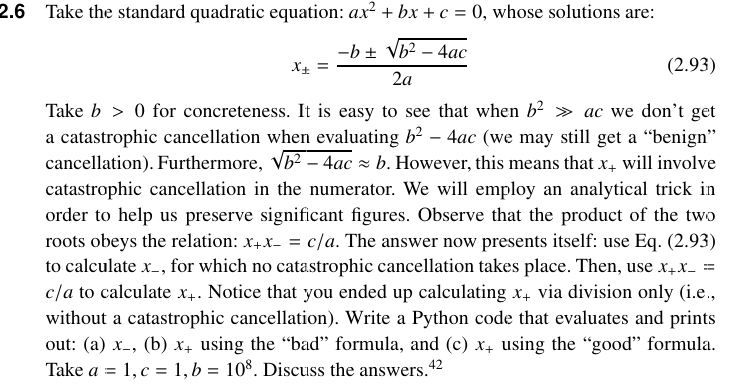

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import math

# variables for quadratic eqn
a = 1.0
b = 10**8
c = 1.0

# (a) x_
x_minus = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)

# (b) x+ using the "bad" formula
x_plus_bad = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

# (c) x+ using the "good" formula: x+ = c / (a * x_)
x_plus_good = (c / a) / x_minus

print(f"x_minus: {x_minus}")
print(f"x_plus (bad): {x_plus_bad}")
print(f"x_plus (good): {x_plus_good}")

x_minus: -100000000.0
x_plus (bad): -7.450580596923828e-09
x_plus (good): -1e-08


In [39]:
# This script compares a standard quadratic formula with a stable method using Vieta's relation for equations with large b-values. 
# It runs both formulas to show how risky subtraction ruins accuracy and how division fixes it. 
# This setup was chosen to demonstrate how to avoid precision loss in computer math.

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [ ]:
# Catastrophic cancellation occurs at very large values of x, specifically occurring at around 10^7 for 32-bit, 
# 10^16 for 62-bit, and 10^19 for 124 bit.

In [32]:
# To avoid catastrophic cancellation, we can rewrite the function by multiplying and dividing the original function by 
# its conjugate (sqrt(x^2 + x) + x), resulting to x / (sqrt(x^2 + x) + x). This new function changes the denominator into a 
# sum rather than a difference. Given this, the rewritten function does not collapse to 0 as x approaches infinity.

/tmp/ipykernel_2891262/2218118531.py:8: RuntimeWarning: overflow encountered in square
  y_32 = np.sqrt(x.astype(np.float32)**2 + x.astype(np.float32)) - x.astype(np.float32)


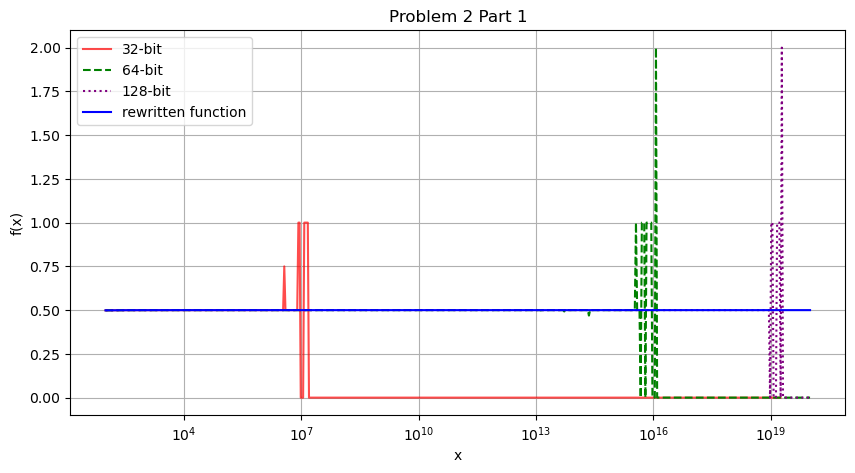

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# test range for large x values
x = np.logspace(2, 20, 600)

# evaluate oiginal "bad" function with different float types: f(x) = sqrt(x^2 + x) - x
y_32 = np.sqrt(x.astype(np.float32)**2 + x.astype(np.float32)) - x.astype(np.float32)
y_64 = np.sqrt(x.astype(np.float64)**2 + x.astype(np.float64)) - x.astype(np.float64)
y_128 = np.sqrt(x.astype(np.float128)**2 + x.astype(np.float128)) - x.astype(np.float128)

# evaluate rewritten conjugate function: f(x) = x / (sqrt(x^2 + x) + x)
y_good = x / (np.sqrt(x**2 + x) + x)

# plot
plt.figure(figsize=(10, 5))
plt.plot(x, y_32, label="32-bit", color="red", alpha=0.7)
plt.plot(x, y_64, label="64-bit", color="green", linestyle="--")
plt.plot(x, y_128, label="128-bit", color="purple", linestyle=":")
plt.plot(x, y_good, label="rewritten function", color="blue")

plt.xscale('log')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Problem 2 Part 1")
plt.legend()
plt.grid(True)
plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [ ]:
# Catastrophic cancellation occurs when x approaches zero, specifically occurring at around 10^7 for 32-bit, 10^16 for 64-bit, 
# and 10^20 for 128-bit.

In [34]:
# To avoid catastrophic cancellation, we can rewrite the function by using NumPy's `np.expm1(x)` function instead of 
# manually calculating e^x - 1. When x approaches zero, e^x becomes almost equal to 1, meaning the computer has to subtract 
# two nearly identical numbers. Since computers can only store a fixed number of digits, this subtraction washes out the 
# true value and results to 0. Using `np.expm1(x)` avoids this subtraction entirely by calculating the tiny change directly, 
# keeping the final result accurate.

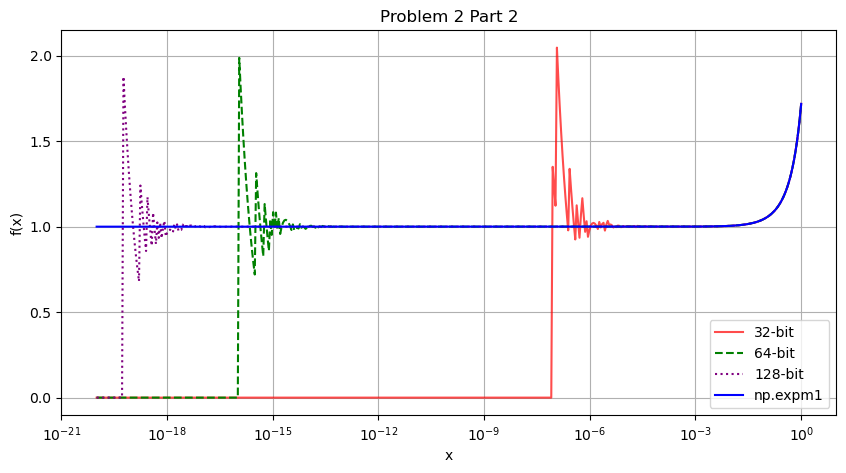

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# values approaching 0
x = np.logspace(-20, 0, 500)

# evaluate oiginal "bad" function with different float types: f(x) = (exp(x) - 1) / x
y_32 = (np.exp(x.astype(np.float32)) - 1) / x.astype(np.float32)
y_64 = (np.exp(x.astype(np.float64)) - 1) / x.astype(np.float64)
y_128 = (np.exp(x.astype(np.float128)) - 1) / x.astype(np.float128)

# evaluate using numpy special function np.expm1
y_good = np.expm1(x) / x

# plot
plt.figure(figsize=(10, 5))
plt.plot(x, y_32, label="32-bit", color="red", alpha=0.7)
plt.plot(x, y_64, label="64-bit", color="green", linestyle="--")
plt.plot(x, y_128, label="128-bit", color="purple", linestyle=":")
plt.plot(x, y_good, label="np.expm1", color="blue")

plt.xscale('log')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Problem 2 Part 2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# This script compares problematic math functions with their fixed versions across different computer precisions (32-bit to 128-bit). 
# It plots both versions on graphs to show where the original formulas fail and how the fixes restore correct values. 
# This structure was chosen to make it easy to see the limits of computer precision and how math adjustments solve them.

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)